---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Breck Meagher 
    orcid: 0009-0009-0293-3406
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": False,
        "font.family": "serif",
        #"font.serif": "DejaVu Serif",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

## **Transmitted Field Dither Locking**

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


### **Plot of Fabry-Perot $E_\mathrm{refl}$ versus $E_\mathrm{trans}$**

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?

---
Transmission is always maximized and reflection is minimized at $\phi=0$ (resonance), but the critically coupled case has 0 reflected field at resonance.

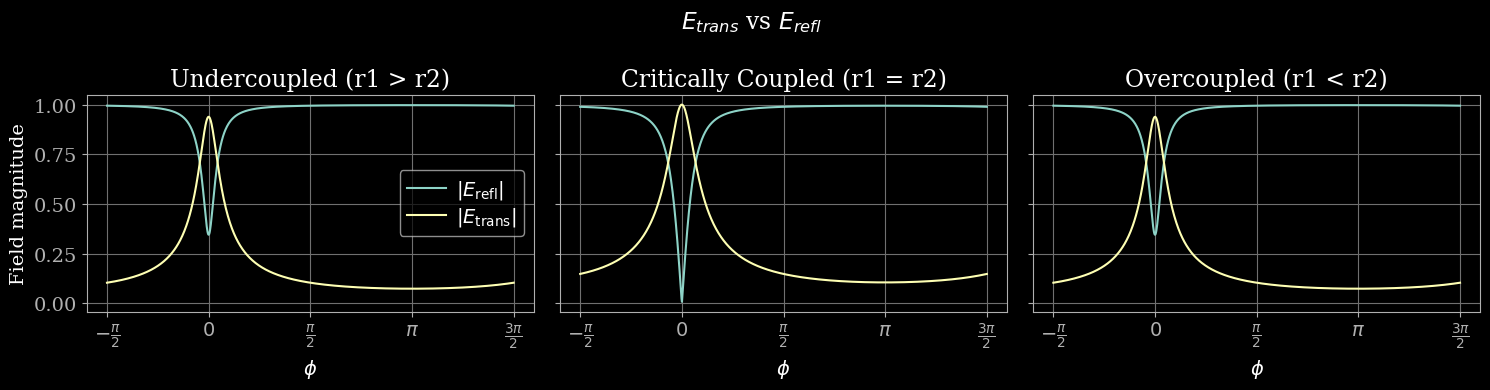

In [15]:
plt.close('all')

# phi range
phi = np.linspace(-np.pi/2, 3*np.pi/2, 1000)
E_in = 1.0

def compute_fields(r1, r2):
    """
    compute E_trans and E_refl
    """
    t1 = np.sqrt(1 - r1**2)
    t2 = np.sqrt(1 - r2**2)
    
    den = 1 - r1 * r2 * np.exp(-1j * phi)
    
    E_refl = (r1 - (t1**2 * r2 * np.exp(-1j * phi)) / den) * E_in
    E_trans = (t1 * t2 * np.exp(-1j * phi / 2) / den) * E_in
    
    return np.abs(E_refl), np.abs(E_trans)

# define coupling
cases = {
    "Undercoupled (r1 > r2)": (0.95, 0.9),
    "Critically Coupled (r1 = r2)": (0.9, 0.9),
    "Overcoupled (r1 < r2)": (0.9, 0.95),
}

# custom pi ticks
pi_ticks = [-np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2]
pi_labels = [
    r'$-\frac{\pi}{2}$',
    r'$0$',
    r'$\frac{\pi}{2}$',
    r'$\pi$',
    r'$\frac{3\pi}{2}$'
]

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (title, (r1, r2)) in zip(axes, cases.items()):
    E_refl, E_trans = compute_fields(r1, r2)
    
    ax.plot(phi, E_refl, label=r'$|E_{\mathrm{refl}}|$')
    ax.plot(phi, E_trans, label=r'$|E_{\mathrm{trans}}|$')
    
    ax.set_title(title)
    ax.set_xlabel(r'$\phi$')
    ax.set_xticks(pi_ticks)
    ax.set_xticklabels(pi_labels)
    ax.grid(True)

axes[0].set_ylabel('Field magnitude')
axes[0].legend()

plt.suptitle(r'$E_{trans}$ vs $E_{refl}$')
plt.tight_layout()
plt.show()

### **Total $E_\mathrm{trans}$ with end-mirror moduation**  

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?

---
When the end mirror is modulated as
$$
x(t) = x_0 + \Delta x \cos(\omega t)
$$
the cavity length becomes time-dependent. Define phase as:
$$
\phi(t) = kL(t)
$$

Then:
$$
\phi(t) = k\big(L + \Delta x \cos(\omega t)\big) = \phi_0 + k\Delta x \cos(\omega t)
$$

The transmitted field is:
$$
E_{\mathrm{trans}}(t) = \frac{t_1 t_2 e^{-i\phi(t)}}{1 - r_1 r_2 e^{-i 2\phi(t)}} E_{\mathrm{in}}
$$

Substituting $\phi(t)$ gives:
$$
\boxed{
E_{\mathrm{trans}}(t)=
\frac{t_1 t_2 , e^{-i\left(\phi_0 + k\Delta x \cos(\omega t)\right)}}{
1 - r_1 r_2 , e^{-i\left(2\phi_0 + 2k\Delta x \cos(\omega t)\right)}}
E_{\mathrm{in}}
}
$$

---

#### **Transfer function from $E_{\mathrm{cav2}}$ to $E_{\mathrm{trans}}$**

$$
E_{\mathrm{trans}} = t_2 e^{-i\phi} E_{\mathrm{cav}},
\quad
E_{\mathrm{cav}} = -r_1 e^{-i\phi} E_{\mathrm{cav2}}
$$

So:
$$
E_{\mathrm{trans}} = -t_2 r_1 e^{-i2\phi} E_{\mathrm{cav2}}
$$

Including cavity buildup (loop suppression):
$$
\frac{E_{\mathrm{cav2}}}{E_{\mathrm{cav2}}}=
\frac{1}{1 - r_1 r_2 e^{-i2\phi}}
$$

Thus the transfer function is:
$$
\frac{E_{\mathrm{trans}}}{E_{\mathrm{cav2}}}=
\frac{-t_2 r_1 e^{-i2\phi}}{1 - r_1 r_2 e^{-i2\phi}}
$$

#### **Carrier field incident on the end mirror**
Same as before:
$$
E_{\mathrm{cav,end}} =
\frac{t_1 e^{-i\phi}}{1 - r_1 r_2 e^{-i2\phi}} E_{\mathrm{in}}
$$

#### **Apply mirror modulation**
Apply the modulation:
$$
x(t) = x_0 + \Delta x \cos(\omega t)
$$

This produces three fields:
$$
E_{\mathrm{cav2}} = E_{\mathrm{cav2,0}} + E_{\mathrm{cav2,usb}} + E_{\mathrm{cav2,lsb}}
$$

with:
* **Carrier:**
  $$
  E_{\mathrm{cav2,0}} = r_2 E_{\mathrm{cav,end}}
  $$

* **Upper sideband:**
  $$
  E_{\mathrm{cav2,usb}} = i k \Delta x , r_2 E_{\mathrm{cav,end}} e^{i\omega t}
  $$

* **Lower sideband:**
  $$
  E_{\mathrm{cav2,lsb}} = i k \Delta x , r_2 E_{\mathrm{cav,end}} e^{-i\omega t}
  $$


#### **Apply transfer function to each component**

Define:
$$
\eta = \frac{\omega L}{c}
$$

* Carrier sees phase $\phi$
* Upper sideband sees $\phi + \eta$
* Lower sideband sees $\phi - \eta$

**Carrier contribution**
$$
E_{\mathrm{trans,0}} =
\frac{-t_2 r_1 e^{-i2\phi}}{1 - r_1 r_2 e^{-i2\phi}}
\cdot
E_{\mathrm{cav2,0}}
$$


**Upper sideband**
$$
E_{\mathrm{trans,usb}} =
\frac{-t_2 r_1 e^{-i2(\phi+\eta)}}{1 - r_1 r_2 e^{-i2(\phi+\eta)}}
\cdot
E_{\mathrm{cav2,usb}}
$$

**Lower sideband**
$$
E_{\mathrm{trans,lsb}} =
\frac{-t_2 r_1 e^{-i2(\phi-\eta)}}{1 - r_1 r_2 e^{-i2(\phi-\eta)}}
\cdot
E_{\mathrm{cav2,lsb}}
$$


#### **Total transmitted field**

Adding all contributions:
$$
\boxed{
E_{\mathrm{trans}}(t)=
\Big(
E_{\mathrm{trans,0}}
+
E_{\mathrm{trans,usb}}
+
E_{\mathrm{trans,lsb}}
\Big) e^{i\omega_0 t}
}
$$

You can maybe write this as:
$$
E_{\mathrm{trans}}(t)=
E_0 e^{i\omega_0 t}
+
E_+ e^{i(\omega_0 + \omega)t}
+
E_- e^{i(\omega_0 - \omega)t}
$$

where:

* $E_0$ = carrier transmitted through cavity
* $E_\pm$ = sidebands generated by mirror motion and filtered by cavity



In [24]:
import sympy as sp

# symbols
phi, eta, omega, omega0, t = sp.symbols('phi eta omega omega0 t', real=True)
k, dx = sp.symbols('k dx', real=True)
r1, r2, t1 = sp.symbols('r1 r2 t1', real=True)
E0 = sp.symbols('E0')
I = sp.I

# common denominator (carrier)
D_phi = 1 - r1*r2*sp.exp(-2*I*phi)

# cavity field at end mirror (carrier buildup)
Ecav_end = t1 * sp.exp(-I*phi) / D_phi

# fields reflected off end mirror
Ecav2_0   = r2 * Ecav_end
Ecav2_usb = I * k * dx * r2 * Ecav_end * sp.exp(I*omega*t)
Ecav2_lsb = I * k * dx * r2 * Ecav_end * sp.exp(-I*omega*t)

# transfer function Ecav2 -> E_trans
def TF(phi_val):
    return (-t1 * sp.exp(-I*phi_val)) / (1 - r1*r2*sp.exp(-2*I*phi_val))

# apply transfer functions
Etrans_0   = TF(phi)       * Ecav2_0
Etrans_usb = TF(phi+eta)   * Ecav2_usb
Etrans_lsb = TF(phi-eta)   * Ecav2_lsb

# total field
Etrans_total = (Etrans_0 + Etrans_usb + Etrans_lsb) * E0 * sp.exp(I*omega0*t)

# # simplify (optional)
# Etrans_total = sp.simplify(Etrans_total)

Etrans_total

E0*(-I*dx*k*r2*t1**2*exp(-I*phi)*exp(-I*(eta + phi))*exp(I*omega*t)/((-r1*r2*exp(-2*I*phi) + 1)*(-r1*r2*exp(-2*I*(eta + phi)) + 1)) - I*dx*k*r2*t1**2*exp(-I*phi)*exp(-I*(-eta + phi))*exp(-I*omega*t)/((-r1*r2*exp(-2*I*phi) + 1)*(-r1*r2*exp(-2*I*(-eta + phi)) + 1)) - r2*t1**2*exp(-2*I*phi)/(-r1*r2*exp(-2*I*phi) + 1)**2)*exp(I*omega0*t)


---


### **Calculate the total transmitted power $P_\mathrm{trans}(t)$**

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

---


In [33]:
from sympy import expand, simplify, I, cos, sin

# replace complex exponentials with cos+I*sin so Re() can simplify
def make_real(expr):
    return expr.expand(complex=True).rewrite(sp.exp, sp.cos)  # rewrite exponentials as cos + I*sin

# expand each term
Etrans_0_real   = make_real(Etrans_0)
Etrans_usb_real = make_real(Etrans_usb)
Etrans_lsb_real = make_real(Etrans_lsb)

# total transmitted power (small dx)
P_trans = Abs(Etrans_0_real)**2 + 2*re(conjugate(Etrans_0_real)*(Etrans_usb_real + Etrans_lsb_real))

# # fully expand and simplify
# P_trans = simplify(expand(P_trans))

P_trans

KeyboardInterrupt: 

### **Calculate the transmitted power demodulated at $\omega$** 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

---

### **Plot the length to transmitted power function phase sweep**
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

---

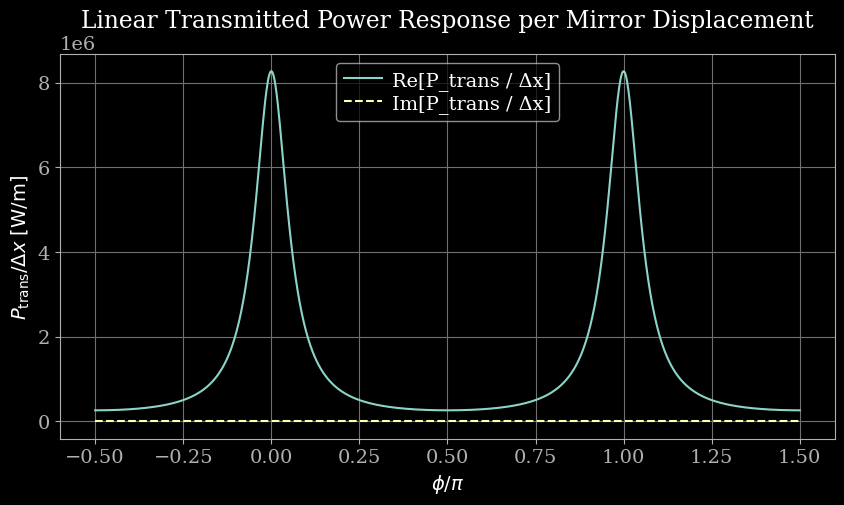

In [34]:
# ---------------------------
# Cavity parameters
L = 1.0              # m
Pin = 1.0            # W
T1 = 0.3             # Input mirror transmissivity
T2 = 0.3             # Output mirror transmissivity
R1 = 1 - T1
R2 = 1 - T2
lambda0 = 1064e-9    # m
k = 2 * np.pi / lambda0
omega = 2 * np.pi * 100  # Hz

# Carrier phase range
phi = np.linspace(-np.pi/2, 3*np.pi/2, 1000)

# ---------------------------
# Transmitted carrier field
# E_trans0 = t2 * r2 * t1 / (1 - r1 * r2 * exp(-2i phi)) * sqrt(Pin)
Etrans0 = np.sqrt(Pin) * np.sqrt(T1*T2) * np.sqrt(R2) / (1 - np.sqrt(R1*R2) * np.exp(-2j*phi))

# ---------------------------
# Linear response per dx
# P_trans / dx = 2 * k * |Etrans0|^2
Ptrans_per_dx = 2 * k * np.abs(Etrans0)**2

# ---------------------------
# Plot real and imaginary parts
plt.figure(figsize=(10,5))
plt.plot(phi/np.pi, np.real(Ptrans_per_dx), label='Re[P_trans / Δx]')
plt.plot(phi/np.pi, np.imag(Ptrans_per_dx), label='Im[P_trans / Δx]', linestyle='--')
plt.xlabel(r'$\phi / \pi$')
plt.ylabel(r'$P_\mathrm{trans} / \Delta x~[\mathrm{W/m}]$')
plt.title('Linear Transmitted Power Response per Mirror Displacement')
plt.grid(True)
plt.legend()
plt.show()

### **Plot the length to transmitted power transfer function**

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

---

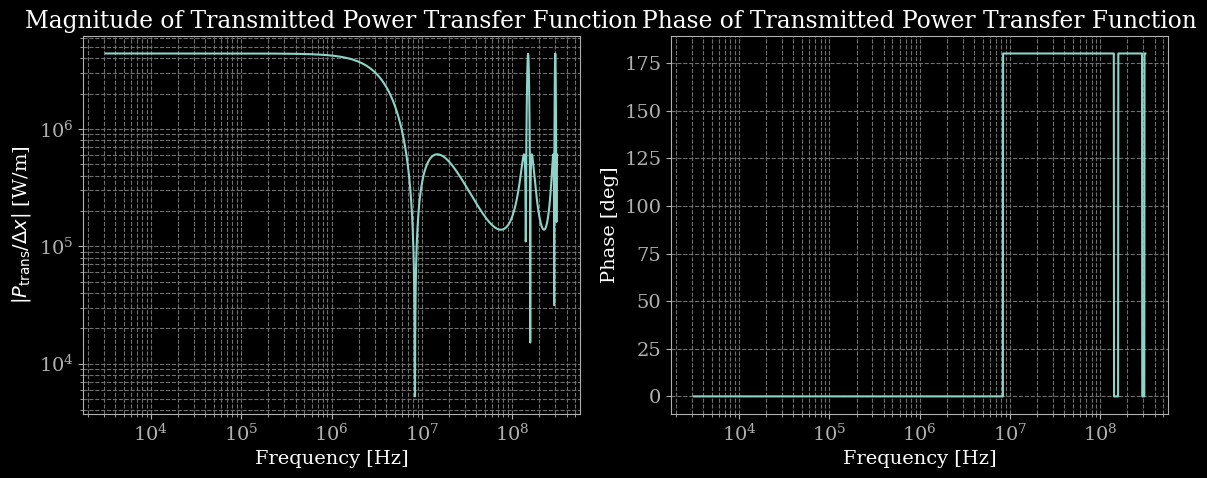

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Cavity parameters
L = 1.0             # m
Pin = 1.0           # W
T1 = 0.3
T2 = 0.3
R1 = 1 - T1
R2 = 1 - T2
lambda0 = 1064e-9
k = 2 * np.pi / lambda0
phi_deg = 1.0
phi = np.deg2rad(phi_deg)

c = 3e8  # m/s

# Frequency range
f = np.logspace(3.5, 8.5, 2000)  # 3e3 to 3e8 Hz
omega = 2 * np.pi * f
eta = omega * L / c

# ---------------------------
# Carrier transmitted field
Etrans0 = np.sqrt(Pin) * np.sqrt(T1*T2) * np.sqrt(R2) / (1 - np.sqrt(R1*R2) * np.exp(-2j*phi))

# ---------------------------
# Sidebands transmitted field
Etrans_usb = 1j * k * np.sqrt(T2) * np.sqrt(R2) * np.sqrt(T1) * np.sqrt(Pin) / (1 - np.sqrt(R1*R2) * np.exp(-2j*phi)) / (1 - np.sqrt(R1*R2) * np.exp(-2j*(phi + eta)))
Etrans_lsb = 1j * k * np.sqrt(T2) * np.sqrt(R2) * np.sqrt(T1) * np.sqrt(Pin) / (1 - np.sqrt(R1*R2) * np.exp(-2j*phi)) / (1 - np.sqrt(R1*R2) * np.exp(-2j*(phi - eta)))

# Linear response per dx (drop Δx for plotting per unit dx)
Ptrans_per_dx = 2 * np.real(np.conjugate(Etrans0) * (Etrans_usb + Etrans_lsb))

# ---------------------------
# Magnitude and phase
Pmag = np.abs(Ptrans_per_dx)
Pphase = np.angle(Ptrans_per_dx)

# ---------------------------
# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.loglog(f, Pmag)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|P_\mathrm{trans}/\Delta x|$ [W/m]')
plt.title('Magnitude of Transmitted Power Transfer Function')
plt.grid(True, which='both', ls='--')

plt.subplot(1,2,2)
plt.semilogx(f, np.degrees(Pphase))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [deg]')
plt.title('Phase of Transmitted Power Transfer Function')
plt.grid(True, which='both', ls='--')

plt.tight_layout()
plt.show()

## **Pound-Drever-Hall Michelson**

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

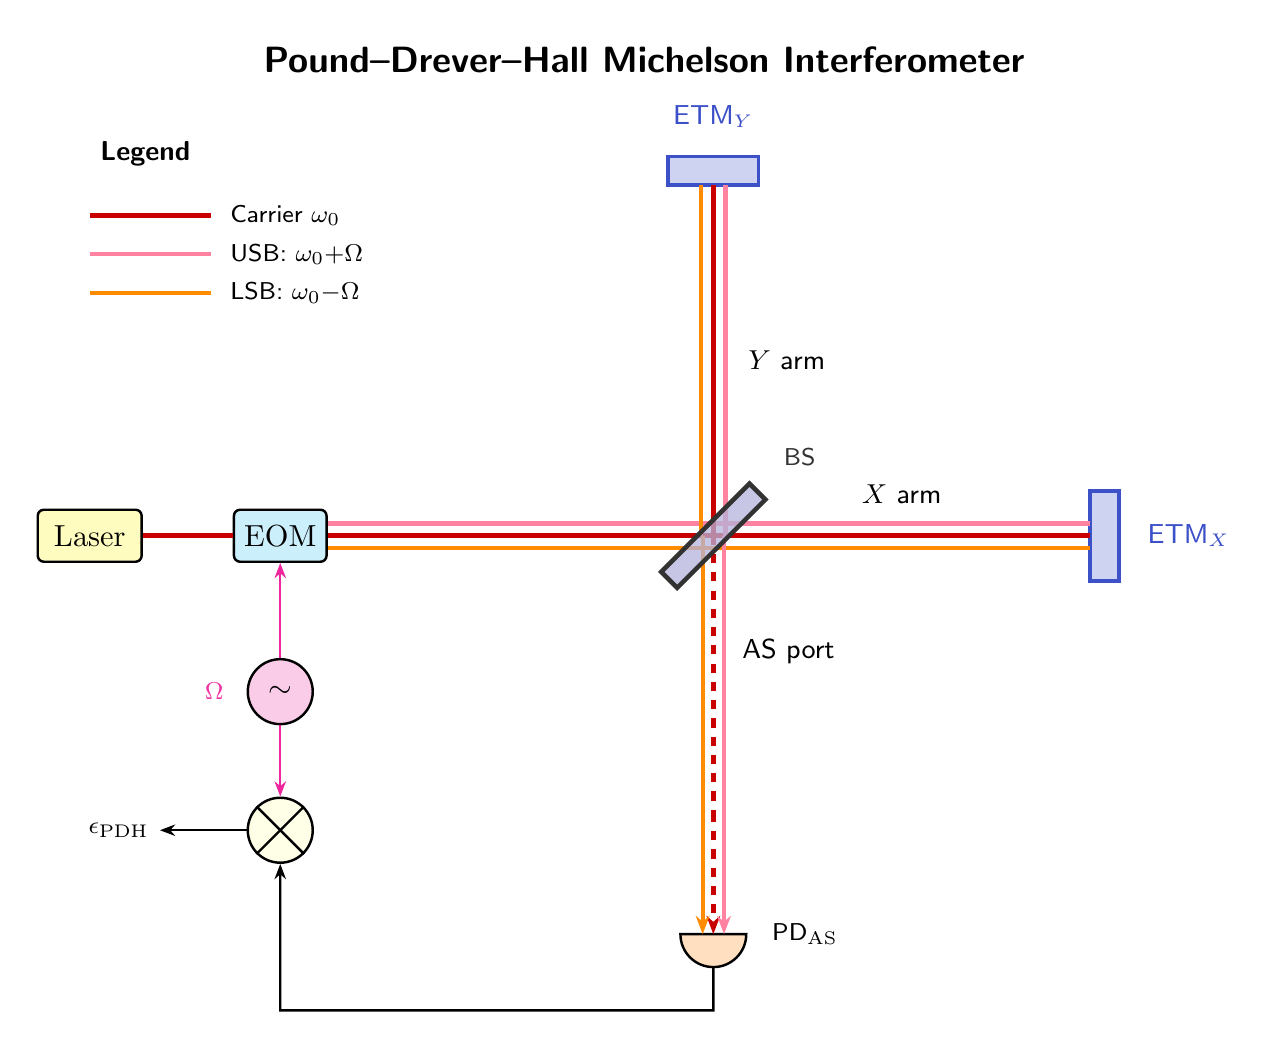

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?


# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

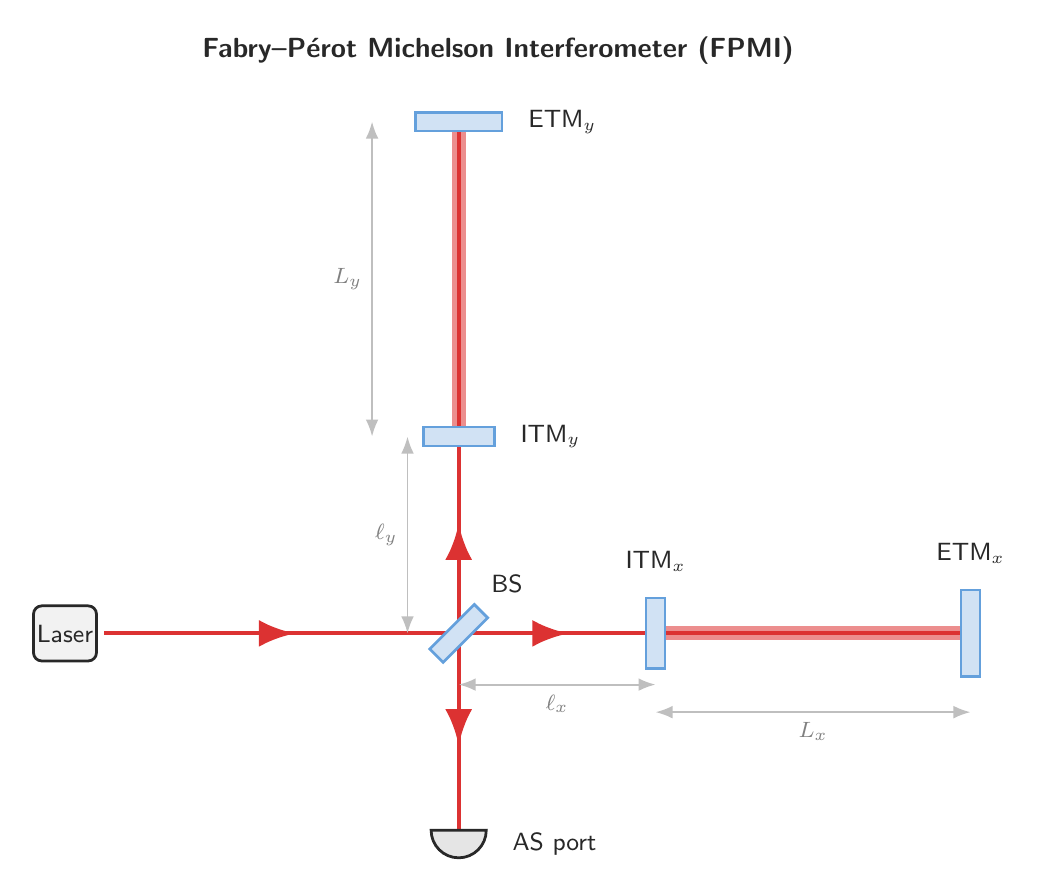

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}


